# BEAD RF — SHAP, Ablation, and Feature Importance Analysis
Loads the pre-saved enriched dataset, trains the final integrated model, and produces:
1. Feature ablation table
2. Normalized feature importance table (RF Gini, SHAP, LIME)
3. SHAP beeswarm summary plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Load pre-saved enriched dataset ─────────────────────────────────────────
df_raw = pd.read_csv('fp_enriched.csv')
df_raw['log_funding'] = np.log1p(df_raw['funding_per_location'])

low  = df_raw['funding_per_location'].quantile(0.025)
high = df_raw['funding_per_location'].quantile(0.975)
df = df_raw[(df_raw['funding_per_location'] >= low) & (df_raw['funding_per_location'] <= high)].copy()

print(f'Trimmed dataset: {df.shape[0]} projects')

Trimmed dataset: 5429 projects


In [2]:

# ── Feature set (19 features) ────────────────────────────────────────────────
# Dropped: frac_fiber_comp, frac_cable_comp, frac_fw_comp (redundant with tech fracs)
FEATURE_COLS = [
    # Technology mix
    'frac_tech_40',
    'frac_tech_50',
    'frac_tech_61',
    'frac_tech_71',
    # Project-level
    'miles_per_location',
    'pct_aerial',
    'pct_cai',
    'n_total',
    # Competition (Dec 2024 NBM)
    'frac_competitor_qualifying',
    'frac_wired_qualifying',
    # ISP incumbency / coverage
    'prov_coverage',
    'frac_present_at_location',
    'nearest_mi_served_same_isp',
    'nearest_mi_served_any',
    'no_prior_presence_frac',
    # Geography — county-level weighted means
    'POPDEN_RUR_wmean',
    'POPDEN_COU_wmean',
    'rucc_code_wmean',
    'poverty_rate_wmean',
]

pretty_names_map = {
    'frac_tech_40':               'frac_tech_40',
    'frac_tech_50':               'frac_tech_50',
    'frac_tech_61':               'frac_tech_61 (fiber)',
    'frac_tech_71':               'frac_tech_71 (FW)',
    'miles_per_location':         'miles_per_loc',
    'pct_aerial':                 'pct_aerial',
    'pct_cai':                    'pct_cai',
    'n_total':                    'n_total',
    'frac_competitor_qualifying': 'frac_q_comp',
    'frac_wired_qualifying':      'frac_q_wired',
    'prov_coverage':              'isp_coverage',
    'frac_present_at_location':   'frac_presence',
    'nearest_mi_served_same_isp': 'nearest_own_mi',
    'nearest_mi_served_any':      'nearest_any_mi',
    'no_prior_presence_frac':     'no_prior_presence',
    'POPDEN_RUR_wmean':           'rur_popden',
    'POPDEN_COU_wmean':           'cou_popden',
    'rucc_code_wmean':            'rucc_code',
    'poverty_rate_wmean':         'poverty_rate',
}

X = df[FEATURE_COLS].fillna(0)
y = df['log_funding']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.3,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

baseline_r2   = r2_score(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
baseline_mae  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')

print(f'Features: {len(FEATURE_COLS)}')
print(f'Test R²  (log): {baseline_r2:.4f}')
print(f'CV R²   (log): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'RMSE (real $): ${baseline_rmse:,.0f}')
print(f'MAE  (real $): ${baseline_mae:,.0f}')


Features: 19
Test R²  (log): 0.7245
CV R²   (log): 0.7246 ± 0.0183
RMSE (real $): $3,495
MAE  (real $): $1,847


## 1. Feature Ablation

In [3]:
ablation_results = []

for feat in FEATURE_COLS:
    cols_reduced = [c for c in FEATURE_COLS if c != feat]
    X_tr = X_train[cols_reduced]
    X_te = X_test[cols_reduced]

    rf_ab = RandomForestRegressor(
        n_estimators=200, min_samples_split=2, min_samples_leaf=1,
        max_features=0.3, max_depth=20, random_state=42, n_jobs=-1
    )
    rf_ab.fit(X_tr, y_train)
    yp = rf_ab.predict(X_te)

    r2   = r2_score(y_test, yp)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(yp)))
    mae  = mean_absolute_error(np.expm1(y_test), np.expm1(yp))

    ablation_results.append({
        'feature': feat,
        'r2':      r2,
        'delta_r2': r2 - baseline_r2,
        'rmse':    rmse,
        'mae':     mae,
    })
    print(f'  {feat:35s}  R²={r2:.4f}  ΔR²={r2-baseline_r2:+.4f}  RMSE=${rmse:,.0f}')

abl_df = pd.DataFrame(ablation_results).sort_values('delta_r2')
print(f'\nBaseline Test R² = {baseline_r2:.4f}')

  frac_tech_40                         R²=0.7268  ΔR²=+0.0023  RMSE=$3,471


  frac_tech_50                         R²=0.7267  ΔR²=+0.0022  RMSE=$3,476
  frac_tech_61                         R²=0.7289  ΔR²=+0.0045  RMSE=$3,475


  frac_tech_71                         R²=0.7231  ΔR²=-0.0014  RMSE=$3,488
  miles_per_location                   R²=0.6910  ΔR²=-0.0334  RMSE=$3,587


  pct_aerial                           R²=0.7197  ΔR²=-0.0048  RMSE=$3,496
  pct_cai                              R²=0.7191  ΔR²=-0.0053  RMSE=$3,483


  n_total                              R²=0.7162  ΔR²=-0.0082  RMSE=$3,663
  frac_competitor_qualifying           R²=0.7295  ΔR²=+0.0050  RMSE=$3,390


...

  prov_coverage                        R²=0.7254  ΔR²=+0.0010  RMSE=$3,488
  frac_present_at_location             R²=0.7212  ΔR²=-0.0033  RMSE=$3,491


  nearest_mi_served_same_isp           R²=0.7243  ΔR²=-0.0002  RMSE=$3,479
  nearest_mi_served_any                R²=0.7235  ΔR²=-0.0009  RMSE=$3,482


  no_prior_presence_frac               R²=0.7227  ΔR²=-0.0018  RMSE=$3,489
  POPDEN_RUR_wmean                     R²=0.7053  ΔR²=-0.0191  RMSE=$3,686


  POPDEN_COU_wmean                     R²=0.7236  ΔR²=-0.0008  RMSE=$3,458
  rucc_code_wmean                      R²=0.7227  ΔR²=-0.0017  RMSE=$3,467


  poverty_rate_wmean                   R²=0.7193  ΔR²=-0.0052  RMSE=$3,471

Baseline Test R² = 0.7245


In [4]:
# ── LaTeX: Ablation table ────────────────────────────────────────────────────
print(r"""\begin{table*}[ht]
\centering""")
print(f"""\\caption{{Feature ablation results. Baseline Test $R^2 = {baseline_r2:.4f}$.}}
\\label{{tab:ablation}}
\\begin{{tabularx}}{{\\textwidth}}{{>{{\\ttfamily}}Xcccc}}
\\toprule
\\textbf{{Feature}} & \\textbf{{Test $R^2$}} & \\textbf{{$\\Delta R^2$}} & \\textbf{{RMSE (\\$)}} & \\textbf{{MAE (\\$)}} \\\\
\\midrule""")

neg_rows = abl_df[abl_df['delta_r2'] <= 0].sort_values('delta_r2')
pos_rows = abl_df[abl_df['delta_r2'] > 0].sort_values('delta_r2', ascending=False)

for _, row in neg_rows.iterrows():
    feat = row['feature'].replace('_', '\\_')
    sign = '+' if row['delta_r2'] >= 0 else '-'
    print(f"{feat:45s} & {row['r2']:.4f} & ${row['delta_r2']:+.4f}$ & "
          f"{row['rmse']:,.0f} & {row['mae']:,.0f} \\\\")

if not pos_rows.empty:
    print(r"\hhline{=====}")
    for _, row in pos_rows.iterrows():
        feat = row['feature'].replace('_', '\\_')
        print(f"{feat:45s} & {row['r2']:.4f} & ${row['delta_r2']:+.4f}$ & "
              f"{row['rmse']:,.0f} & {row['mae']:,.0f} \\\\")

print(r"""\bottomrule
\end{tabularx}
\end{table*}""")

\begin{table*}[ht]
\centering
\caption{Feature ablation results. Baseline Test $R^2 = 0.7245$.}
\label{tab:ablation}
\begin{tabularx}{\textwidth}{>{\ttfamily}Xcccc}
\toprule
\textbf{Feature} & \textbf{Test $R^2$} & \textbf{$\Delta R^2$} & \textbf{RMSE (\$)} & \textbf{MAE (\$)} \\
\midrule
miles\_per\_location                          & 0.6910 & $-0.0334$ & 3,587 & 1,983 \\
POPDEN\_RUR\_wmean                            & 0.7053 & $-0.0191$ & 3,686 & 1,919 \\
n\_total                                      & 0.7162 & $-0.0082$ & 3,663 & 1,877 \\
pct\_cai                                      & 0.7191 & $-0.0053$ & 3,483 & 1,851 \\
poverty\_rate\_wmean                          & 0.7193 & $-0.0052$ & 3,471 & 1,842 \\
pct\_aerial                                   & 0.7197 & $-0.0048$ & 3,496 & 1,862 \\
frac\_present\_at\_location                   & 0.7212 & $-0.0033$ & 3,491 & 1,844 \\
no\_prior\_presence\_frac                     & 0.7227 & $-0.0018$ & 3,489 & 1,842 \\
rucc\_code\_wmean     

## 2. SHAP Analysis

In [5]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap', '-q'])
    import shap

print(f'SHAP version: {shap.__version__}')

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')

SHAP version: 0.52.0


SHAP values shape: (1629, 19)


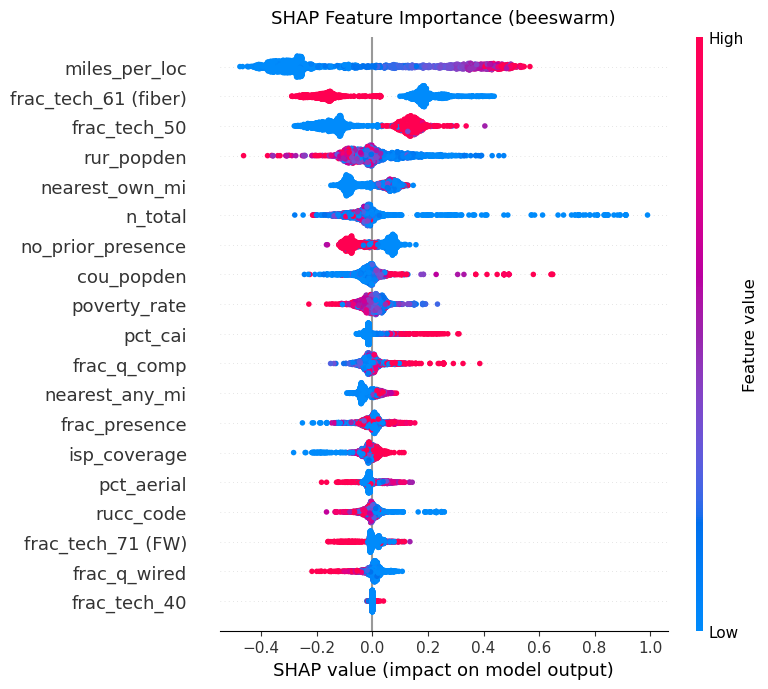

Saved: shap_beeswarm.pdf / shap_beeswarm.png


In [6]:

# ── SHAP beeswarm summary plot ───────────────────────────────────────────────
plot_names = [pretty_names_map[c] for c in FEATURE_COLS]

fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=plot_names,
    show=False,
    plot_size=None,
    color_bar_label='Feature value'
)
plt.title('SHAP Feature Importance (beeswarm)', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('shap_beeswarm.pdf', bbox_inches='tight', dpi=150)
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: shap_beeswarm.pdf / shap_beeswarm.png')


## 3. Normalized Importance Table (RF Gini + SHAP)

In [7]:

# ── Collect and normalize ────────────────────────────────────────────────────
gini_raw = rf.feature_importances_
shap_raw = np.abs(shap_values).mean(axis=0)

def norm(arr):
    s = arr.sum()
    return arr / s if s > 0 else arr

importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'pretty':  [pretty_names_map[c] for c in FEATURE_COLS],
    'gini':    norm(gini_raw),
    'shap':    norm(shap_raw),
}).sort_values('shap', ascending=False)

print(importance_df[['pretty','gini','shap']].to_string(index=False))


              pretty     gini     shap
       miles_per_loc 0.196797 0.242662
frac_tech_61 (fiber) 0.079387 0.154591
        frac_tech_50 0.100138 0.119794
          rur_popden 0.076401 0.061835
      nearest_own_mi 0.050196 0.059684
             n_total 0.080399 0.059635
   no_prior_presence 0.039406 0.052882
          cou_popden 0.079148 0.032012
        poverty_rate 0.045776 0.025621
             pct_cai 0.016384 0.023918
         frac_q_comp 0.039052 0.023698
      nearest_any_mi 0.031980 0.023289
       frac_presence 0.029714 0.023159
        isp_coverage 0.029211 0.021113
          pct_aerial 0.023972 0.020233
           rucc_code 0.036431 0.019403
   frac_tech_71 (FW) 0.019992 0.017958
        frac_q_wired 0.024298 0.017933
        frac_tech_40 0.001319 0.000577


In [8]:
# ── LaTeX: Normalized importance table (Gini + SHAP) ────────────────────────
print(r"""\begin{table}[h]
  \centering
  \caption{Normalized feature importance from RF Gini and SHAP}
  \label{tab:importance_comparison}
  \begin{tabular}{lcc}
  \hline
  \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} \\\\
  \hline""")

for _, row in importance_df.iterrows():
    feat = '\\texttt{' + row['pretty'].replace('_', '\\_') + '}'
    print(f"  {feat:50s} & {row['gini']:.3f} & {row['shap']:.3f} \\\\")

print(r"""  \hline
  \end{tabular}
\end{table}""")


\begin{table}[h]
  \centering
  \caption{Normalized feature importance from RF Gini and SHAP}
  \label{tab:importance_comparison}
  \begin{tabular}{lcc}
  \hline
  \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} \\\\
  \hline
  \texttt{miles\_per\_loc}                           & 0.197 & 0.243 \\
  \texttt{frac\_tech\_61 (fiber)}                    & 0.079 & 0.155 \\
  \texttt{frac\_tech\_50}                            & 0.100 & 0.120 \\
  \texttt{rur\_popden}                               & 0.076 & 0.062 \\
  \texttt{nearest\_own\_mi}                          & 0.050 & 0.060 \\
  \texttt{n\_total}                                  & 0.080 & 0.060 \\
  \texttt{no\_prior\_presence}                       & 0.039 & 0.053 \\
  \texttt{cou\_popden}                               & 0.079 & 0.032 \\
  \texttt{poverty\_rate}                             & 0.046 & 0.026 \\
  \texttt{pct\_cai}                                  & 0.016 & 0.024 \\
  \texttt{frac\_q\_comp}                          

In [9]:
# ── Save importance data to CSV ──────────────────────────────────────────────
importance_df.to_csv('feature_importances.csv', index=False)
abl_df.to_csv('ablation_results.csv', index=False)
print('Saved feature_importances.csv and ablation_results.csv')

Saved feature_importances.csv and ablation_results.csv
